# Exploration des variables calendaires

## Objectif

Ce notebook présente une analyse exploratoire des variables calendaires construites pour le projet de prévision de la consommation électrique.

Le calendrier couvre la période du **1er décembre 2015 au 31 décembre 2025** avec une observation par jour.

Les variables étudiées sont :

- le jour de la semaine ;
- le mois ;
- l'indicateur de week-end ;
- les jours fériés ;
- les veilles et lendemains de jours fériés ;
- les ponts potentiels ;
- les vacances scolaires des zones A, B et C ;
- le nombre de zones simultanément en vacances.

L'objectif est de vérifier la structure des données et de comprendre la répartition temporelle de ces variables avant leur utilisation comme variables explicatives dans les modèles de prévision.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

# Racine du projet
PROJECT_ROOT = Path.cwd().parent

# Permet à Python d'importer les modules du dossier src/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.calendrier import construire_calendrier

In [2]:
print("Dossier du notebook :", Path.cwd())
print("Racine du projet :", PROJECT_ROOT)

Dossier du notebook : C:\Users\marte\OneDrive\Desktop\Projet-series-temporelles\notebooks
Racine du projet : C:\Users\marte\OneDrive\Desktop\Projet-series-temporelles


## 1. Chargement du calendrier

Le calendrier est construit à partir du module `src.calendrier`.

Cette approche permet d'utiliser directement le même calendrier que celui employé dans le pipeline du projet, plutôt que de créer une copie indépendante des données dans le notebook.

In [3]:
calendrier = construire_calendrier()

calendrier.head()

,date,jour_semaine,mois,weekend,ferie,veille_ferie,lendemain_ferie,pont_potentiel,periode_noel,vacances_A,vacances_B,vacances_C,nb_zones_vacances
0,2015-12-01,1,12,0,0,0,0,0,0,0,0,0,0
1,2015-12-02,2,12,0,0,0,0,0,0,0,0,0,0
2,2015-12-03,3,12,0,0,0,0,0,0,0,0,0,0
3,2015-12-04,4,12,0,0,0,0,0,0,0,0,0,0
4,2015-12-05,5,12,1,0,0,0,0,0,0,0,0,0


In [4]:
print("Dimensions :", calendrier.shape)
print(
    "Période :",
    calendrier["date"].min().date(),
    "->",
    calendrier["date"].max().date(),
)
print("Nombre de jours :", len(calendrier))

Dimensions : (3684, 13)
Période : 2015-12-01 -> 2025-12-31
Nombre de jours : 3684


## 2. Contrôles de cohérence

Avant l'analyse graphique, plusieurs contrôles sont réalisés afin de vérifier la qualité du calendrier construit :

- unicité des dates ;
- continuité journalière de la série ;
- absence de valeurs manquantes ;
- cohérence des variables binaires ;
- cohérence du nombre de zones scolaires simultanément en vacances.

Ces vérifications complètent les tests automatiques du projet et permettent de documenter la qualité des données utilisées pour la modélisation.

In [5]:
print("Nombre de lignes :", len(calendrier))
print("Nombre de dates uniques :", calendrier["date"].nunique())
print("Nombre de dates dupliquées :", calendrier["date"].duplicated().sum())

dates_attendues = pd.date_range(
    calendrier["date"].min(),
    calendrier["date"].max(),
    freq="D",
)

dates_manquantes = dates_attendues.difference(calendrier["date"])

print("Nombre de dates manquantes :", len(dates_manquantes))

Nombre de lignes : 3684
Nombre de dates uniques : 3684
Nombre de dates dupliquées : 0
Nombre de dates manquantes : 0


In [6]:
colonnes_binaires = [
    "weekend",
    "ferie",
    "veille_ferie",
    "lendemain_ferie",
    "pont_potentiel",
    "vacances_A",
    "vacances_B",
    "vacances_C",
]

for colonne in colonnes_binaires:
    print(
        f"{colonne:20s} :",
        sorted(calendrier[colonne].unique())
    )

weekend              : [np.int64(0), np.int64(1)]
ferie                : [np.int64(0), np.int64(1)]
veille_ferie         : [np.int64(0), np.int64(1)]
lendemain_ferie      : [np.int64(0), np.int64(1)]
pont_potentiel       : [np.int64(0), np.int64(1)]
vacances_A           : [np.int64(0), np.int64(1)]
vacances_B           : [np.int64(0), np.int64(1)]
vacances_C           : [np.int64(0), np.int64(1)]


In [7]:
somme_zones = (
    calendrier["vacances_A"]
    + calendrier["vacances_B"]
    + calendrier["vacances_C"]
)

print(
    "Valeurs de nb_zones_vacances :",
    sorted(calendrier["nb_zones_vacances"].unique())
)

print(
    "Incohérences avec la somme A+B+C :",
    (calendrier["nb_zones_vacances"] != somme_zones).sum()
)

Valeurs de nb_zones_vacances : [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Incohérences avec la somme A+B+C : 0


## 3. Exploration descriptive des variables calendaires

Cette section étudie la répartition des principales variables calendaires sur la période d'observation.

L'objectif est de comprendre la structure du calendrier avant de mettre ces variables en relation avec la consommation électrique.

On s'intéresse notamment :

- aux jours de la semaine et aux week-ends ;
- aux jours fériés et aux jours situés autour des jours fériés ;
- aux ponts potentiels ;
- aux vacances scolaires et à leur répartition entre les zones A, B et C.

In [8]:
noms_jours = {
    0: "Lundi",
    1: "Mardi",
    2: "Mercredi",
    3: "Jeudi",
    4: "Vendredi",
    5: "Samedi",
    6: "Dimanche",
}

repartition_jours = (
    calendrier["jour_semaine"]
    .value_counts()
    .sort_index()
    .rename(index=noms_jours)
)

repartition_jours

jour_semaine
Lundi       526
Mardi       527
Mercredi    527
Jeudi       526
Vendredi    526
Samedi      526
Dimanche    526
Name: count, dtype: int64

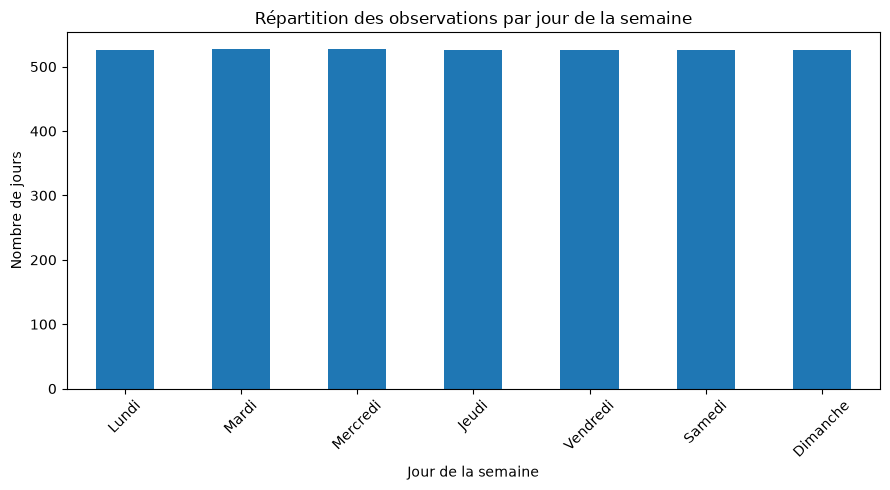

In [9]:
ax = repartition_jours.plot(
    kind="bar",
    figsize=(9, 5),
)

ax.set_title("Répartition des observations par jour de la semaine")
ax.set_xlabel("Jour de la semaine")
ax.set_ylabel("Nombre de jours")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
repartition_weekend = (
    calendrier["weekend"]
    .value_counts()
    .sort_index()
    .rename(
        index={
            0: "Jour de semaine",
            1: "Week-end",
        }
    )
)

repartition_weekend

weekend
Jour de semaine    2632
Week-end           1052
Name: count, dtype: int64

In [11]:
proportion_weekend = (
    calendrier["weekend"].mean() * 100
)

print(
    f"Part des jours de week-end : "
    f"{proportion_weekend:.2f} %"
)

Part des jours de week-end : 28.56 %


In [12]:
variables_feries = [
    "ferie",
    "veille_ferie",
    "lendemain_ferie",
    "pont_potentiel",
]

resume_feries = pd.DataFrame(
    {
        "Nombre de jours": [
            calendrier[colonne].sum()
            for colonne in variables_feries
        ]
    },
    index=[
        "Jour férié",
        "Veille de jour férié",
        "Lendemain de jour férié",
        "Pont potentiel",
    ],
)

resume_feries

,Nombre de jours
Jour férié,111
Veille de jour férié,112
Lendemain de jour férié,111
Pont potentiel,29


In [13]:
feries_par_annee = (
    calendrier
    .assign(annee=calendrier["date"].dt.year)
    .groupby("annee")["ferie"]
    .sum()
)

feries_par_annee

annee
2015     1
2016    11
2017    11
2018    11
2019    11
2020    11
2021    11
2022    11
2023    11
2024    11
2025    11
Name: ferie, dtype: int64

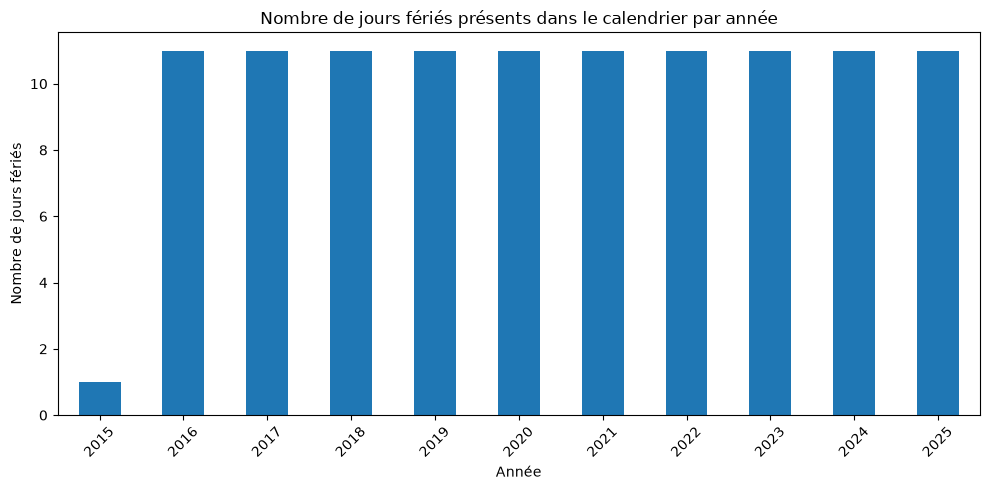

In [14]:
ax = feries_par_annee.plot(
    kind="bar",
    figsize=(10, 5),
)

ax.set_title("Nombre de jours fériés présents dans le calendrier par année")
ax.set_xlabel("Année")
ax.set_ylabel("Nombre de jours fériés")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Exploration des vacances scolaires

Les vacances scolaires sont représentées par trois variables binaires correspondant aux zones A, B et C.

Pour une date donnée :

- `vacances_A = 1` indique que la zone A est en vacances ;
- `vacances_B = 1` indique que la zone B est en vacances ;
- `vacances_C = 1` indique que la zone C est en vacances.

La variable `nb_zones_vacances` synthétise cette information en indiquant le nombre de zones simultanément en vacances, entre 0 et 3.

Cette section étudie la fréquence et le chevauchement de ces périodes sur l'ensemble du calendrier.

In [15]:
jours_vacances_zones = calendrier[
    ["vacances_A", "vacances_B", "vacances_C"]
].sum()

jours_vacances_zones.index = [
    "Zone A",
    "Zone B",
    "Zone C",
]

jours_vacances_zones

Zone A    1233
Zone B    1235
Zone C    1234
dtype: int64

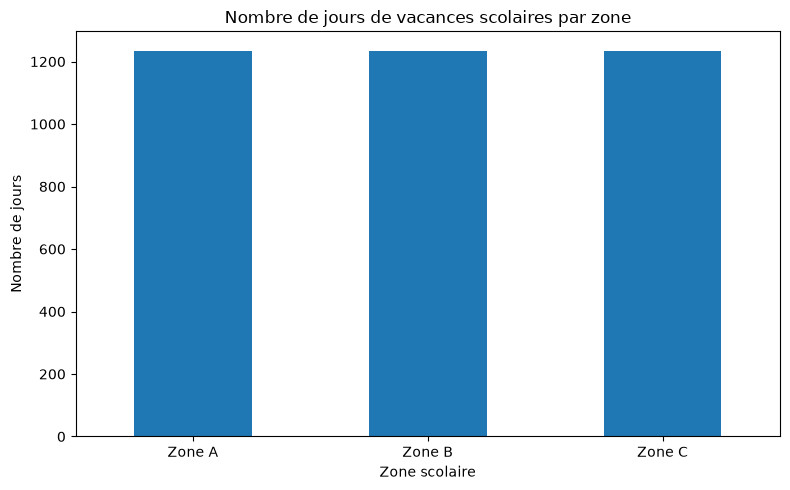

In [16]:
ax = jours_vacances_zones.plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title("Nombre de jours de vacances scolaires par zone")
ax.set_xlabel("Zone scolaire")
ax.set_ylabel("Nombre de jours")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
repartition_nb_zones = (
    calendrier["nb_zones_vacances"]
    .value_counts()
    .sort_index()
)

resume_nb_zones = pd.DataFrame(
    {
        "Nombre de jours": repartition_nb_zones,
        "Pourcentage": (
            repartition_nb_zones
            / len(calendrier)
            * 100
        ).round(2),
    }
)

resume_nb_zones.index.name = "Nombre de zones en vacances"

resume_nb_zones

,Nombre de jours,Pourcentage
Nombre de zones en vacances,,
0,2184,59.28
1,267,7.25
2,264,7.17
3,969,26.30


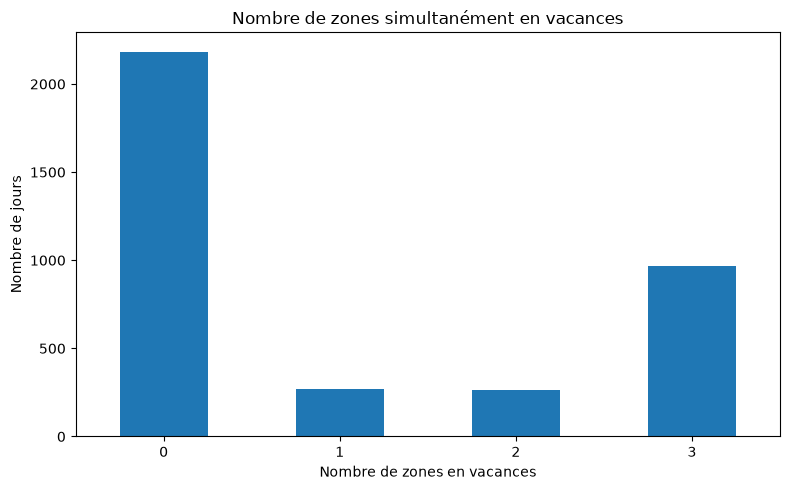

In [18]:
ax = resume_nb_zones["Nombre de jours"].plot(
    kind="bar",
    figsize=(8, 5),
)

ax.set_title("Nombre de zones simultanément en vacances")
ax.set_xlabel("Nombre de zones en vacances")
ax.set_ylabel("Nombre de jours")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
vacances_par_annee = (
    calendrier
    .assign(annee=calendrier["date"].dt.year)
    .groupby("annee")[
        ["vacances_A", "vacances_B", "vacances_C"]
    ]
    .sum()
)

vacances_par_annee

,vacances_A,vacances_B,vacances_C
annee,,,
2015,13,13,13
2016,123,123,123
2017,118,117,118
2018,123,123,123
2019,123,124,123
2020,125,125,125
2021,123,123,123
2022,121,121,121
2023,117,118,118


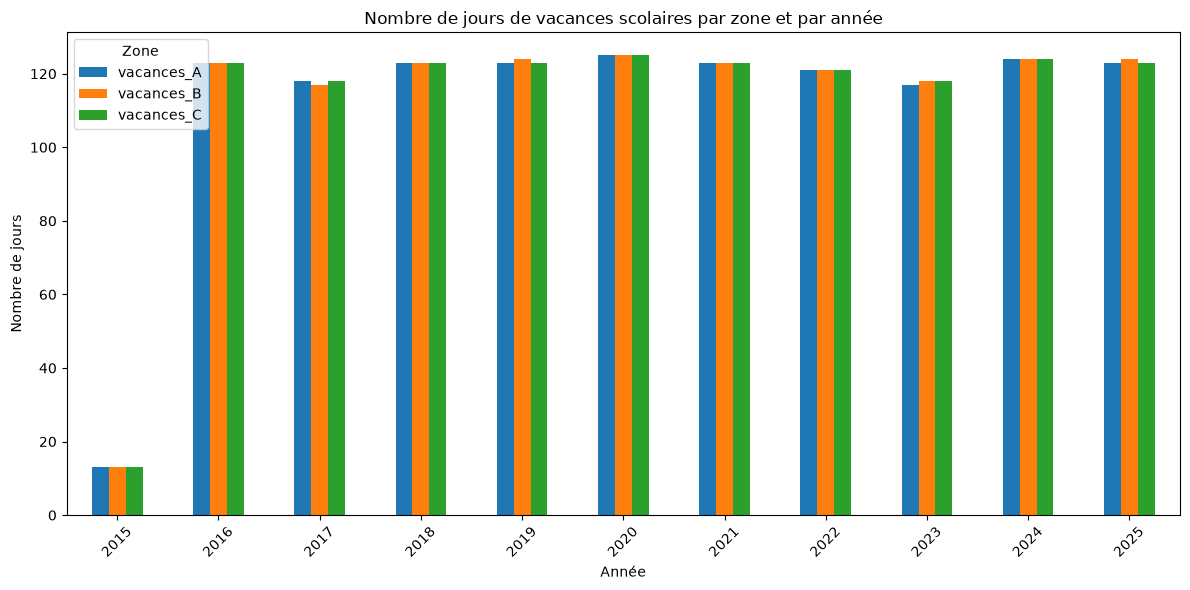

In [20]:
ax = vacances_par_annee.plot(
    kind="bar",
    figsize=(12, 6),
)

ax.set_title("Nombre de jours de vacances scolaires par zone et par année")
ax.set_xlabel("Année")
ax.set_ylabel("Nombre de jours")

plt.xticks(rotation=45)
plt.legend(title="Zone")
plt.tight_layout()
plt.show()

In [21]:
hiver_2018 = calendrier[
    calendrier["date"].between(
        "2018-02-01",
        "2018-03-20",
    )
].copy()

hiver_2018[
    [
        "date",
        "vacances_A",
        "vacances_B",
        "vacances_C",
        "nb_zones_vacances",
    ]
].head()

,date,vacances_A,vacances_B,vacances_C,nb_zones_vacances
793,2018-02-01,0,0,0,0
794,2018-02-02,0,0,0,0
795,2018-02-03,0,0,0,0
796,2018-02-04,0,0,0,0
797,2018-02-05,0,0,0,0


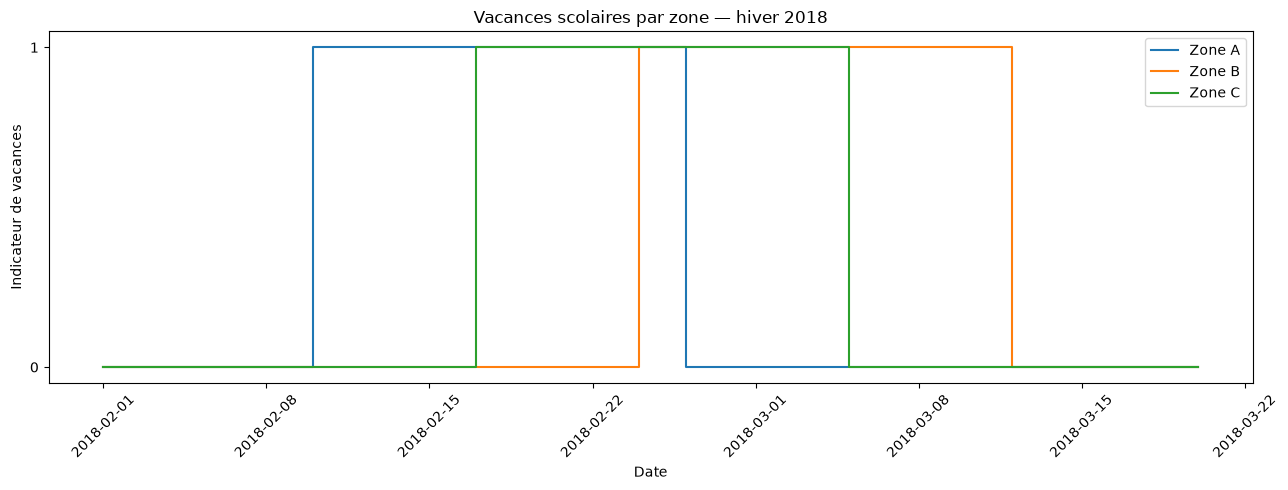

In [22]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.step(
    hiver_2018["date"],
    hiver_2018["vacances_A"],
    where="post",
    label="Zone A",
)

ax.step(
    hiver_2018["date"],
    hiver_2018["vacances_B"],
    where="post",
    label="Zone B",
)

ax.step(
    hiver_2018["date"],
    hiver_2018["vacances_C"],
    where="post",
    label="Zone C",
)

ax.set_title("Vacances scolaires par zone — hiver 2018")
ax.set_xlabel("Date")
ax.set_ylabel("Indicateur de vacances")
ax.set_yticks([0, 1])
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Analyse

La figure met en évidence le décalage des vacances d'hiver 2018 entre les trois zones scolaires. La zone A est en vacances du 10 au 25 février, la zone C du 17 février au 4 mars et la zone B du 24 février au 11 mars.

Les périodes de vacances se chevauchent progressivement. Une seule zone est d'abord en vacances, puis deux zones, avant une courte période les 24 et 25 février durant laquelle les trois zones sont simultanément en vacances. Le phénomène s'inverse ensuite avec la reprise successive des cours dans les zones A, C puis B.

Cette structure justifie la conservation des trois indicateurs `vacances_A`, `vacances_B` et `vacances_C`, ainsi que de la variable synthétique `nb_zones_vacances`. Cette dernière permet de représenter l'étendue des vacances scolaires à l'échelle nationale, tandis que les trois indicateurs conservent l'information sur les zones concernées.

À ce stade, cette analyse décrit uniquement la structure du calendrier scolaire. L'effet éventuel des vacances sur la consommation électrique devra être étudié après la fusion avec les données de consommation RTE.

## 5. Synthèse

L'exploration du calendrier a permis de vérifier la cohérence des variables calendaires construites sur la période du 1er décembre 2015 au 31 décembre 2025.

Le calendrier est continu, sans dates dupliquées ni valeurs manquantes. Les variables binaires associées aux week-ends, jours fériés, veilles et lendemains de jours fériés, ponts potentiels et vacances scolaires présentent également des valeurs cohérentes.

L'analyse des vacances scolaires met en évidence le décalage des périodes de vacances entre les zones A, B et C, notamment pour les vacances d'hiver et de printemps. Les variables `vacances_A`, `vacances_B` et `vacances_C` permettent de conserver cette information géographique, tandis que `nb_zones_vacances` fournit une mesure synthétique du nombre de zones simultanément en vacances.

Ces variables calendaires constituent des variables explicatives potentielles pour la prévision de la consommation électrique. Leur effet réel sur la consommation ne peut toutefois pas être déterminé à partir du calendrier seul. Il devra être étudié après la fusion avec les données de consommation RTE.

La sélection définitive des variables calendaires sera donc réalisée lors de la phase de modélisation, en tenant compte de leur apport prédictif et des éventuelles redondances entre variables.